# Modèle IA v3 — Prédiction de Carences en Vitamines

**Améliorations par rapport au v2 :**
- Ablation study formalisée (impact des features symptômes ~3%)
- Hyperparameter tuning (RandomizedSearchCV)
- RepeatedStratifiedKFold (5 folds × 3 répétitions)
- Courbes ROC par classe
- Courbes d'apprentissage (Learning Curves)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_val_score,
    train_test_split, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
print("Imports OK")


Imports OK


In [2]:

# ── Chargement ──────────────────────────────────────────
csv_path = os.path.join(os.path.dirname(os.getcwd()), 
                        'data_csv', 'raw', 
                        'vitamin_deficiency_disease_dataset_20260123.ods')
df = pd.read_excel(csv_path, engine='odf')
print(f"Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes :\n{df.columns.tolist()}")

# ── Détection automatique de la colonne cible ────────────
target_candidates = ['disease', 'Disease', 'vitamin_deficiency_disease', 
                     'target', 'label', 'condition', 'Condition',
                     'disease_diagnosis']
target_col = None
for col in target_candidates:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    print("\n Colonne cible introuvable — voir la liste des colonnes ci-dessus")
else:
    print(f"\n Colonne cible : '{target_col}'")
    print(f"Classes : {df[target_col].unique()}")

    # ── Suppression des colonnes non cliniques ────────────
    cols_to_drop = [
        'age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption',
        'exercise_level', 'diet_type', 'sun_exposure',
        'latitude_region', 'income_level',
        'symptoms_list', 'symptoms_count'
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    # ── Encodage de la cible ──────────────────────────────
    le = LabelEncoder()
    y = le.fit_transform(df[target_col])
    X = df.drop(columns=[target_col])

    # ── Encodage des colonnes catégorielles ───────────────
    for col in X.select_dtypes(include='object').columns:
        X[col] = LabelEncoder().fit_transform(X[col])

    # ── Split train/test ──────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"\nFeatures conservées : {X.shape[1]}")
    print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
    print(f"\nDistribution :")
    for i, cls in enumerate(le.classes_):
        print(f"  {cls} : {(y==i).sum()}")


Dataset : 4000 lignes × 34 colonnes

Colonnes :
['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'symptoms_list', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'disease_diagnosis', 'has_multiple_deficiencies']

 Colonne cible : 'disease_diagnosis'
Classes : <StringArray>
['Healthy', 'Rickets_Osteomalacia', 'Anemia', 'Night_Blindness', 'Scurvy']
Length: 5, dtype: str

Features conservées : 21
Train : 3200 | Test : 800

Distribution :
  Anemia : 1245
  Healthy : 1509
  Night_Bl

## Section 1 — Ablation Study

Objectif : mesurer l'impact des features symptômes (`has_*`) sur la performance du modèle.

- **Modèle complet** : 21 features (marqueurs biologiques + symptômes)
- **Modèle sans symptômes** : 12 features (marqueurs biologiques uniquement)

> Si la différence est faible, cela confirme que le modèle s'appuie principalement sur les données biologiques (vitamin_c, hemoglobin...) et non sur des symptômes trivialement liés aux maladies.


In [3]:
# ════════════════════════════════════════════════════════
#  SECTION 1 : ABLATION STUDY — Impact des has_*
# ════════════════════════════════════════════════════════

def evaluer_rapide(X_feat, y, label):
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            n_estimators=200, max_depth=15,
            min_samples_split=5, random_state=42
        ))
    ])
    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    scores = cross_val_score(pipe, X_feat, y, cv=rkf, scoring='f1_weighted')
    print(f"\n  {label} ({X_feat.shape[1]} features)")
    print(f"  CV F1 : {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

print("━"*50)
print("  ABLATION STUDY")
print("━"*50)

# Modèle complet
s1 = evaluer_rapide(X, y, "Complet — 21 features")

# Sans symptômes
has_cols = [c for c in X.columns if c.startswith('has_')]
X_no_sym = X.drop(columns=has_cols)
s2 = evaluer_rapide(X_no_sym, y, f"Sans symptômes — {X_no_sym.shape[1]} features")

print(f"\n  Δ F1            : {s1-s2:+.4f}")
print(f"  Part symptômes  : {(s1-s2)/s1*100:.1f}%")
print(f"\n  → Conclusion : les marqueurs biologiques assurent"
      f" {100-(s1-s2)/s1*100:.1f}% de la performance")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ABLATION STUDY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Complet — 21 features (21 features)
  CV F1 : 0.9580 ± 0.0069

  Sans symptômes — 12 features (12 features)
  CV F1 : 0.9288 ± 0.0068

  Δ F1            : +0.0292
  Part symptômes  : 3.1%

  → Conclusion : les marqueurs biologiques assurent 96.9% de la performance


## Section 2 — Hyperparameter Tuning (RandomizedSearchCV)

Objectif : trouver automatiquement les meilleurs paramètres pour chaque modèle
au lieu de les fixer manuellement comme dans le v2.


In [4]:
from scipy.stats import randint, uniform

# ── Grilles de paramètres ────────────────────────────────
param_rf = {
    'rf__n_estimators': randint(100, 500),
    'rf__max_depth': randint(5, 30),
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__max_features': ['sqrt', 'log2']
}

param_svm = {
    'svm__C': uniform(0.1, 50),
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf', 'poly']
}

param_knn = {
    'knn__n_neighbors': randint(3, 20),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# ── Pipelines ────────────────────────────────────────────
pipe_rf = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

pipe_svm = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42, probability=True))
])

pipe_knn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# ── Tuning ───────────────────────────────────────────────
print("Tuning Random Forest...")
search_rf = RandomizedSearchCV(
    pipe_rf, param_rf, n_iter=30, cv=skf,
    scoring='f1_weighted', random_state=42, n_jobs=-1
)
search_rf.fit(X_train, y_train)
print(f"  Meilleurs params RF  : {search_rf.best_params_}")
print(f"  Meilleur CV F1 RF    : {search_rf.best_score_:.4f}")

print("\nTuning SVM...")
search_svm = RandomizedSearchCV(
    pipe_svm, param_svm, n_iter=20, cv=skf,
    scoring='f1_weighted', random_state=42, n_jobs=-1
)
search_svm.fit(X_train, y_train)
print(f"  Meilleurs params SVM : {search_svm.best_params_}")
print(f"  Meilleur CV F1 SVM   : {search_svm.best_score_:.4f}")

print("\nTuning KNN...")
search_knn = RandomizedSearchCV(
    pipe_knn, param_knn, n_iter=20, cv=skf,
    scoring='f1_weighted', random_state=42, n_jobs=-1
)
search_knn.fit(X_train, y_train)
print(f"  Meilleurs params KNN : {search_knn.best_params_}")
print(f"  Meilleur CV F1 KNN   : {search_knn.best_score_:.4f}")


Tuning Random Forest...
  Meilleurs params RF  : {'rf__max_depth': 19, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 8, 'rf__n_estimators': 340}
  Meilleur CV F1 RF    : 0.9601

Tuning SVM...
  Meilleurs params SVM : {'svm__C': np.float64(9.191248360355031), 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
  Meilleur CV F1 SVM   : 0.8936

Tuning KNN...
  Meilleurs params KNN : {'knn__metric': 'manhattan', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
  Meilleur CV F1 KNN   : 0.8241


## Section 3 — Evaluation sur le Test Set

Evaluation des meilleurs modèles obtenus après tuning sur les données de test.



  Random Forest
  Test Accuracy : 0.9425
  Test F1       : 0.9431

                      precision    recall  f1-score   support

              Anemia       0.95      0.96      0.95       249
             Healthy       1.00      0.94      0.97       302
     Night_Blindness       0.92      0.92      0.92        24
Rickets_Osteomalacia       0.87      0.92      0.89       206
              Scurvy       0.95      1.00      0.97        19

            accuracy                           0.94       800
           macro avg       0.94      0.95      0.94       800
        weighted avg       0.94      0.94      0.94       800


  SVM
  Test Accuracy : 0.8925
  Test F1       : 0.8926

                      precision    recall  f1-score   support

              Anemia       0.92      0.88      0.90       249
             Healthy       0.95      0.94      0.95       302
     Night_Blindness       0.54      0.62      0.58        24
Rickets_Osteomalacia       0.84      0.89      0.87       206
  

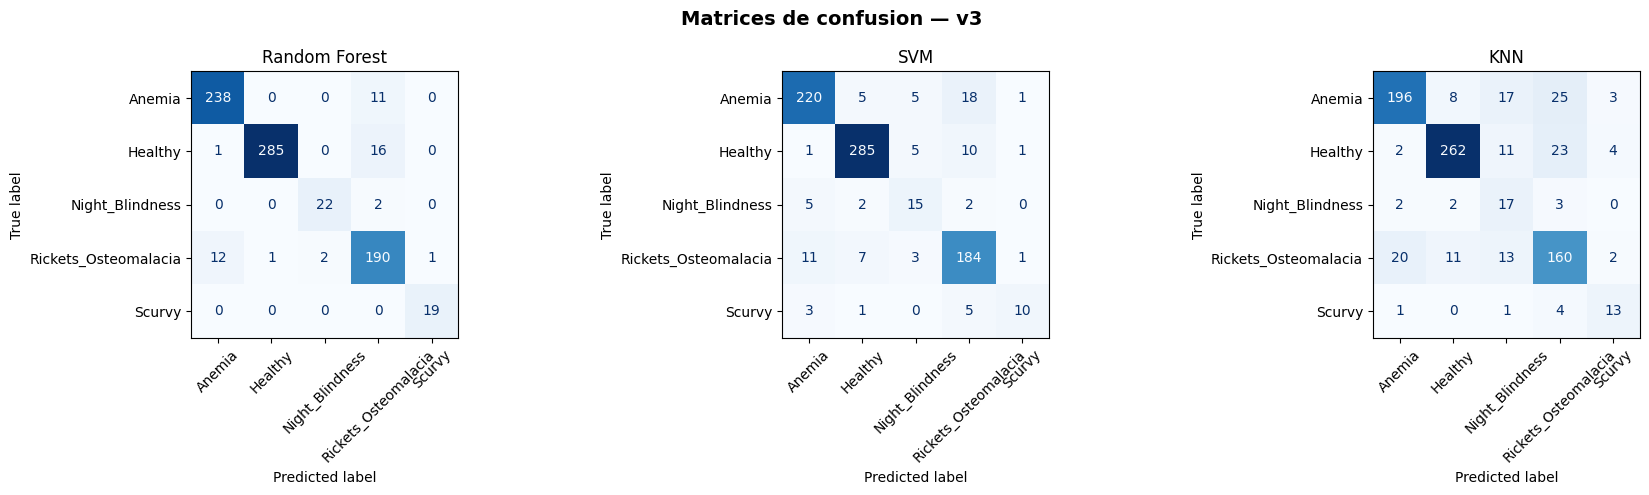

In [5]:
resultats = {}

for nom, search in [('Random Forest', search_rf), 
                    ('SVM', search_svm), 
                    ('KNN', search_knn)]:
    y_pred = search.best_estimator_.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    resultats[nom] = {'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    
    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test F1       : {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")

# Matrice de confusion pour RF
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nom, search) in zip(axes, [('Random Forest', search_rf), 
                                     ('SVM', search_svm), 
                                     ('KNN', search_knn)]):
    cm = confusion_matrix(y_test, resultats[nom]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nom)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de confusion — v3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion_v3.png', dpi=200, bbox_inches='tight')
plt.show()


## Section 4 — Courbes ROC

Une courbe ROC par classe (One-vs-Rest) pour le meilleur modele : Random Forest.
AUC proche de 1.0 = excellent pouvoir discriminant.


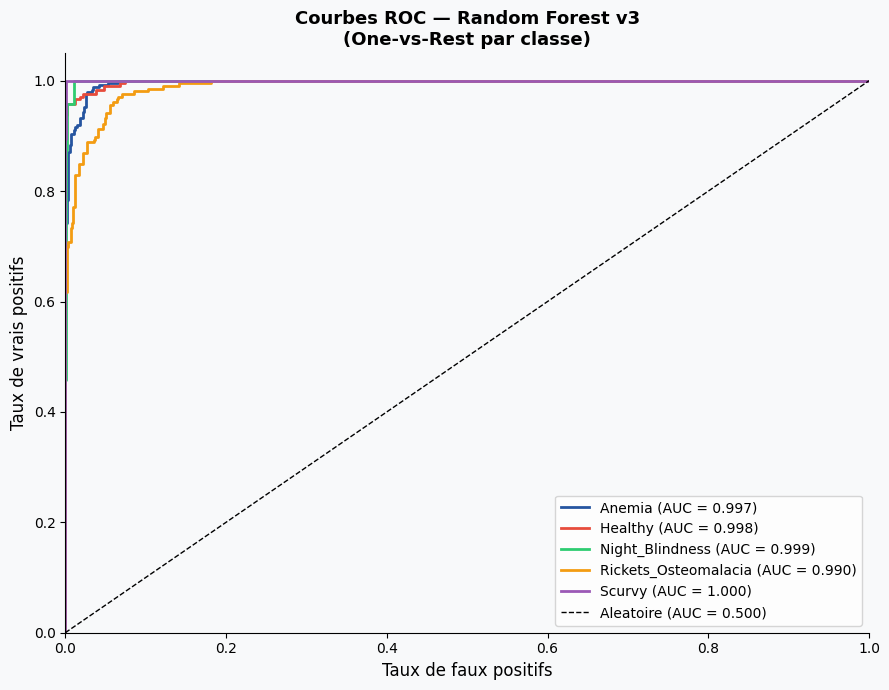

In [6]:
best_model = search_rf.best_estimator_

# Binarisation pour One-vs-Rest
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
y_score    = best_model.predict_proba(X_test)

colors = ['#2655A0', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatoire (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de faux positifs', fontsize=12)
ax.set_ylabel('Taux de vrais positifs', fontsize=12)
ax.set_title('Courbes ROC — Random Forest v3\n(One-vs-Rest par classe)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curves_v3.png', dpi=200, bbox_inches='tight')
plt.show()


## Section 5 — Courbes d'apprentissage

Objectif : verifier qu'il n'y a pas d'overfitting.
- Si train score >> validation score : overfitting
- Si les deux convergent vers un bon score : modele sain


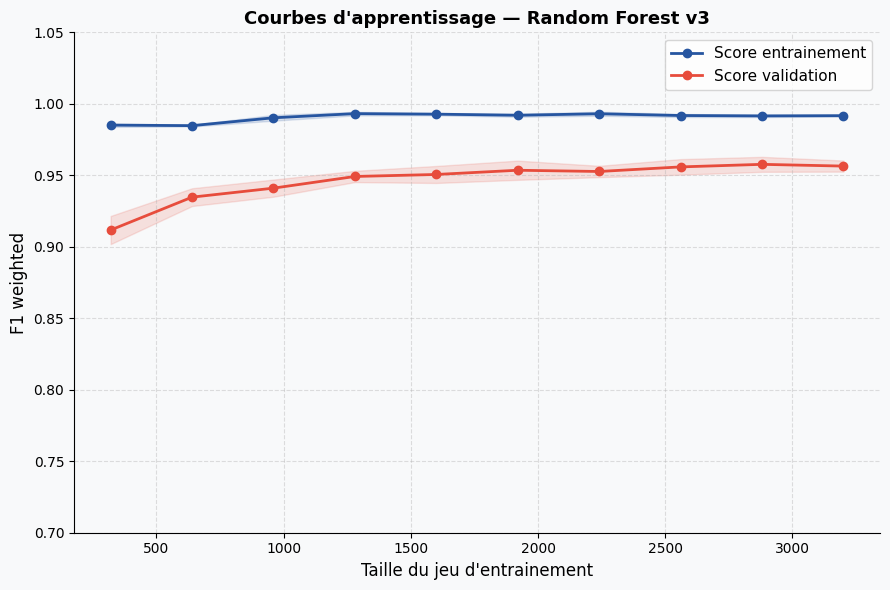

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X, y,
    cv=5,
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

ax.plot(train_sizes, train_mean, 'o-', color='#2655A0',
        linewidth=2, label='Score entrainement')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#2655A0')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c',
        linewidth=2, label='Score validation')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e74c3c')

ax.set_xlabel('Taille du jeu d\'entrainement', fontsize=12)
ax.set_ylabel('F1 weighted', fontsize=12)
ax.set_title('Courbes d\'apprentissage — Random Forest v3',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim([0.7, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('learning_curves_v3.png', dpi=200, bbox_inches='tight')
plt.show()


## Section 6 — Serialisation et Resume Final


In [8]:
# ── Serialisation du meilleur modele ────────────────────
os.makedirs('models_v3', exist_ok=True)

with open('models_v3/best_model_v3.pkl', 'wb') as f:
    pickle.dump(search_rf.best_estimator_, f)

with open('models_v3/label_encoder_v3.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('models_v3/feature_cols_v3.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

# ── Resume comparatif v2 vs v3 ───────────────────────────
print("RESUME COMPARATIF")
print("="*55)
print(f"{'Modele':<25} {'CV F1':>8} {'Test F1':>8} {'Test Acc':>10}")
print("-"*55)
print(f"{'RF v2 (manuel)':<25} {'0.9595':>8} {'0.9444':>8} {'0.9437':>10}")
print(f"{'RF v3 (tuned)':<25} {search_rf.best_score_:>8.4f} "
      f"{resultats['Random Forest']['f1']:>8.4f} "
      f"{resultats['Random Forest']['accuracy']:>10.4f}")
print(f"{'SVM v3 (tuned)':<25} {search_svm.best_score_:>8.4f} "
      f"{resultats['SVM']['f1']:>8.4f} "
      f"{resultats['SVM']['accuracy']:>10.4f}")
print(f"{'KNN v3 (tuned)':<25} {search_knn.best_score_:>8.4f} "
      f"{resultats['KNN']['f1']:>8.4f} "
      f"{resultats['KNN']['accuracy']:>10.4f}")
print("="*55)
print(f"\nFichiers sauvegardes dans models_v3/")
print(f"  best_model_v3.pkl")
print(f"  label_encoder_v3.pkl")
print(f"  feature_cols_v3.pkl")


RESUME COMPARATIF
Modele                       CV F1  Test F1   Test Acc
-------------------------------------------------------
RF v2 (manuel)              0.9595   0.9444     0.9437
RF v3 (tuned)               0.9601   0.9431     0.9425
SVM v3 (tuned)              0.8936   0.8926     0.8925
KNN v3 (tuned)              0.8241   0.8208     0.8100

Fichiers sauvegardes dans models_v3/
  best_model_v3.pkl
  label_encoder_v3.pkl
  feature_cols_v3.pkl
